In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import CategoricalNB

from sklearn.metrics import  accuracy_score, confusion_matrix, classification_report



### load data

In [4]:
df= pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\supervised learning\\Naive bayes\\playtennis.csv")

### data inspection

In [8]:
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes


In [10]:
df.describe()

,Outlook,Temperature,Humidity,Wind,PlayTennis
count,200,200,191,190,200
unique,3,3,2,2,2
top,Rain,Mild,Normal,Weak,Yes
freq,74,73,99,111,120


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB


### handling missing values

In [15]:
df.isnull().mean()*100

Outlook        0.0
Temperature    0.0
Humidity       4.5
Wind           5.0
PlayTennis     0.0
dtype: float64

In [17]:
imputer = SimpleImputer(strategy='most_frequent')

df =pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [19]:
df.isnull().sum()

Outlook        0
Temperature    0
Humidity       0
Wind           0
PlayTennis     0
dtype: int64

In [21]:
df.duplicated().sum()


154

In [23]:
df.drop_duplicates(inplace=True)

In [25]:
# CategoricalNB requires integer-encoded categories.

In [31]:
encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

In [33]:
X=df.drop('PlayTennis',axis=1)
y = df['PlayTennis']



In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_train


,Outlook,Temperature,Humidity,Wind
6,0,2,1,0
30,0,2,0,1
65,1,2,1,0
22,0,0,0,1
20,1,2,0,1
14,2,0,1,0
117,0,0,1,0
18,2,0,1,1
9,0,1,1,1
19,1,1,1,1


In [41]:
model = CategoricalNB()
model.fit(X_train,y_train)



CategoricalNB()

In [43]:
y_pred = model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.7


In [57]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[0.5        0.66666667 0.33333333 0.77777778 0.44444444]
Average Accuracy: 0.5444444444444445


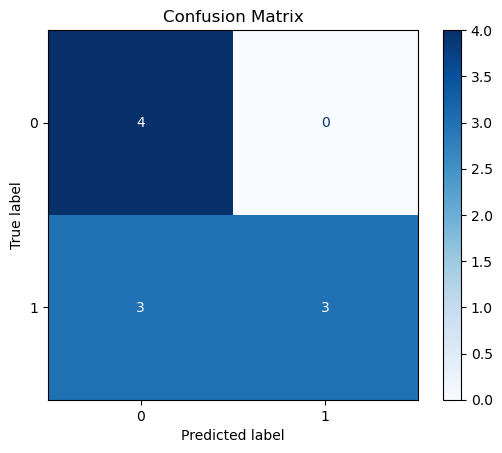

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [55]:
new_data = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

# Encode using the SAME encoders
for column in new_data.columns:
    new_data[column] = encoders[column].transform(new_data[column])

prediction = model.predict(new_data)

# Convert prediction back to text
result = encoders["PlayTennis"].inverse_transform(prediction)

print("\nPrediction for New Data:")
print(result[0])


Prediction for New Data:
No
